### *3.3. REM*

In [ ]:
rem_clasico = pd.read_csv(r"Data\Clasico\REM_Clasico_Largo.csv")
rem_grave = pd.read_csv(r"Data\Grave\REM_Grave_Largo.csv")

In [ ]:

def graficar_panel_rem(df, shp, evento=None):
    """
    Grafica un panel de mapas del REM de dengue en Colombia por años,
    cada uno con su escala individual.
    
    Parámetros:
        df (pd.DataFrame): datos con columnas [departamento, anio, rem].
        shp (gpd.GeoDataFrame): shapefile de Colombia con columna DPTO_CNMBR.
        evento (str, opcional): tipo de evento ("Clásico", "Grave", etc.).
    """

    # === 1. Normalizar nombres ===
    df["departamento"] = df["departamento"].str.upper().str.strip()
    shp["DPTO_CNMBR"] = shp["DPTO_CNMBR"].str.upper().str.strip()

    # === 2. Lista de años únicos ordenados ===
    anios = sorted(df["anio"].unique())

    # === 3. Crear figure y ejes ===
    ncols = 4
    nrows = (len(anios) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 12))
    axes = axes.flatten()

    for i, anio in enumerate(anios):
        ax = axes[i]
        df_anio = df[df["anio"] == anio]
        gdf_anio = shp.merge(df_anio, left_on="DPTO_CNMBR", right_on="departamento", how="left")
        gdf_anio["rem"] = gdf_anio["rem"].fillna(0)

        vmin = gdf_anio["rem"].min()
        vmax = gdf_anio["rem"].max()

        # Graficar mapa
        gdf_anio.plot(
            column="rem",
            cmap="Blues",
            linewidth=0.5,
            edgecolor="0.8",
            vmin=vmin, vmax=vmax,
            ax=ax,
            legend=True,
            legend_kwds={"shrink": 0.6, "label": "REM"}
        )

        ax.set_title(str(anio), fontsize=12, fontweight="bold")
        ax.axis("off")

    # Ocultar subplots vacíos
    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    # === 4. Título global ===
    titulo = f"REM del dengue {evento or 'general'} en Colombia ({anios[0]}–{anios[-1]})"
    fig.suptitle(titulo, fontsize=16, fontweight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


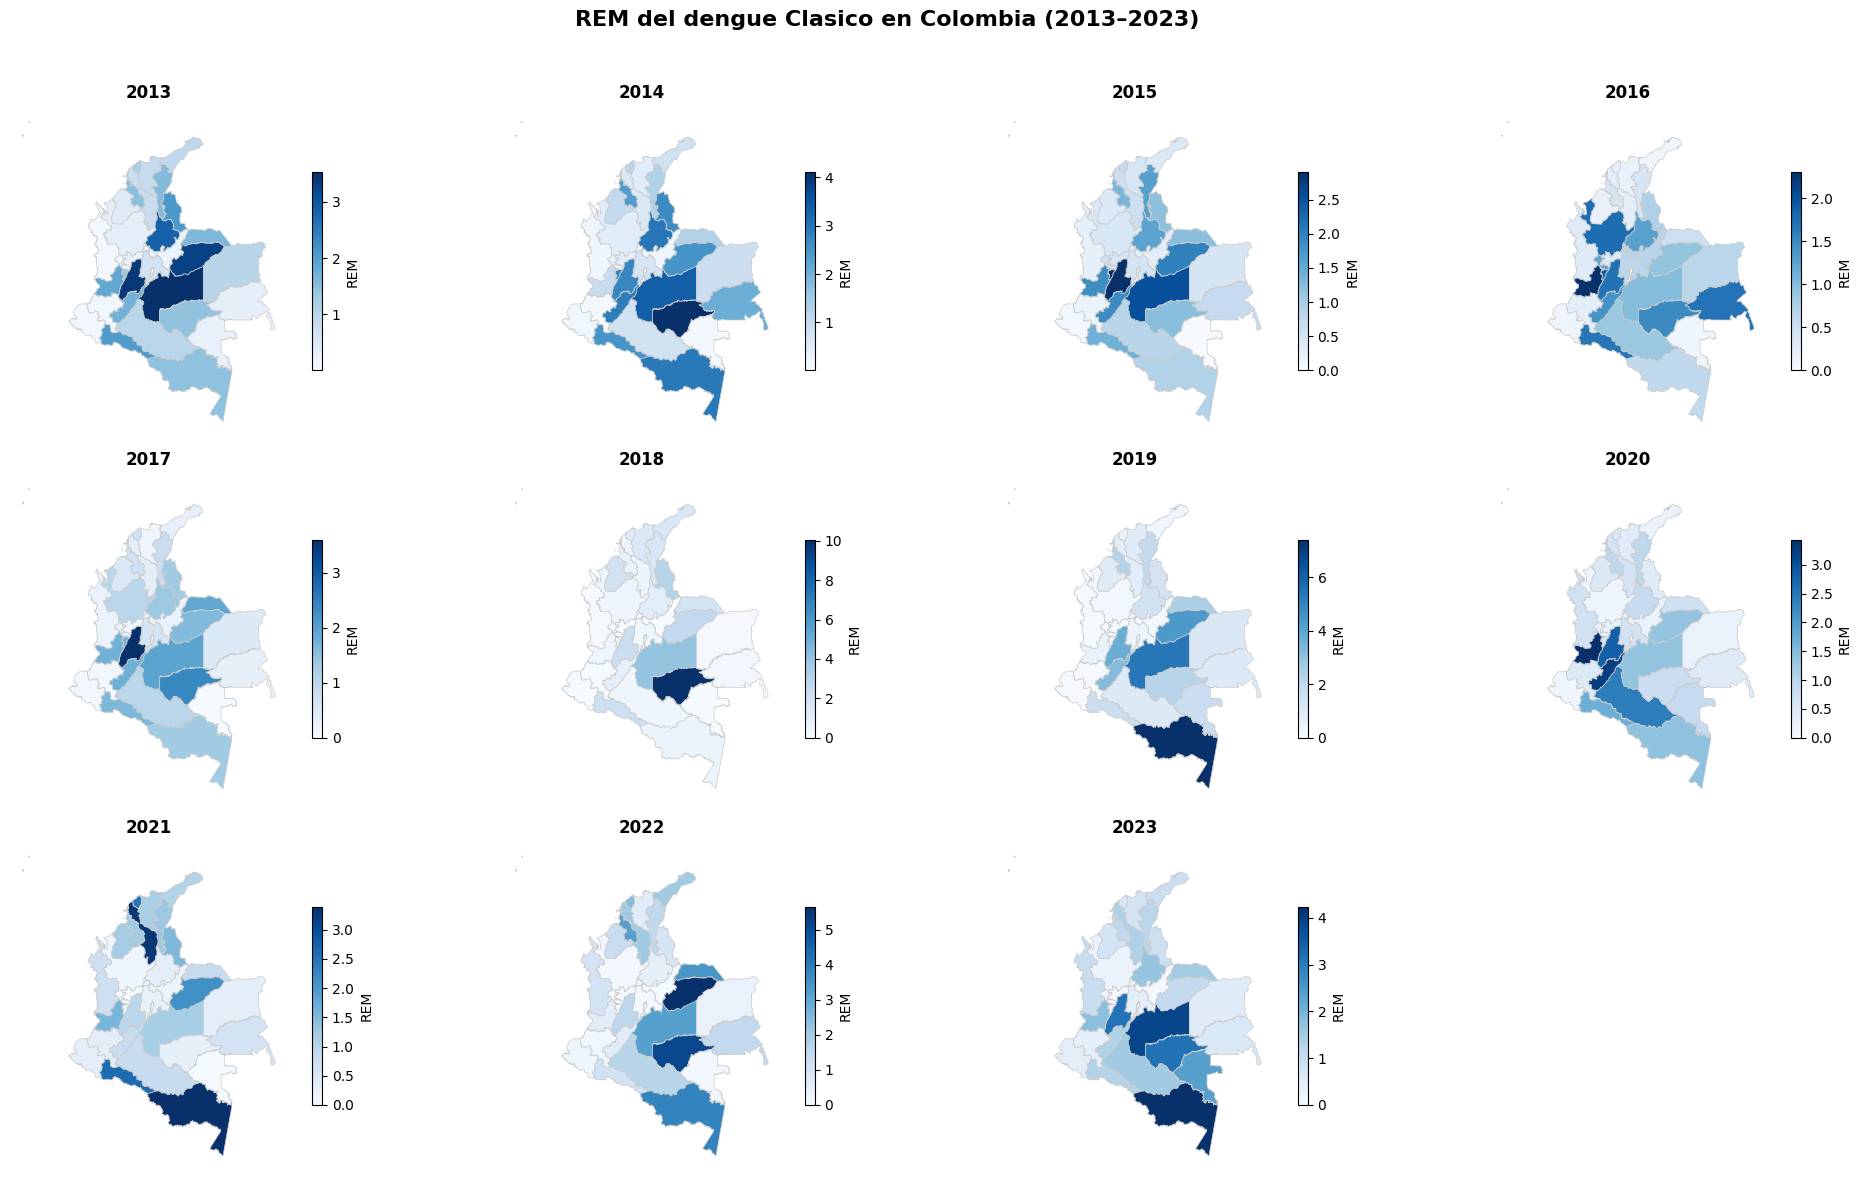

In [ ]:
graficar_panel_rem(rem_clasico, shp, evento="Clasico")

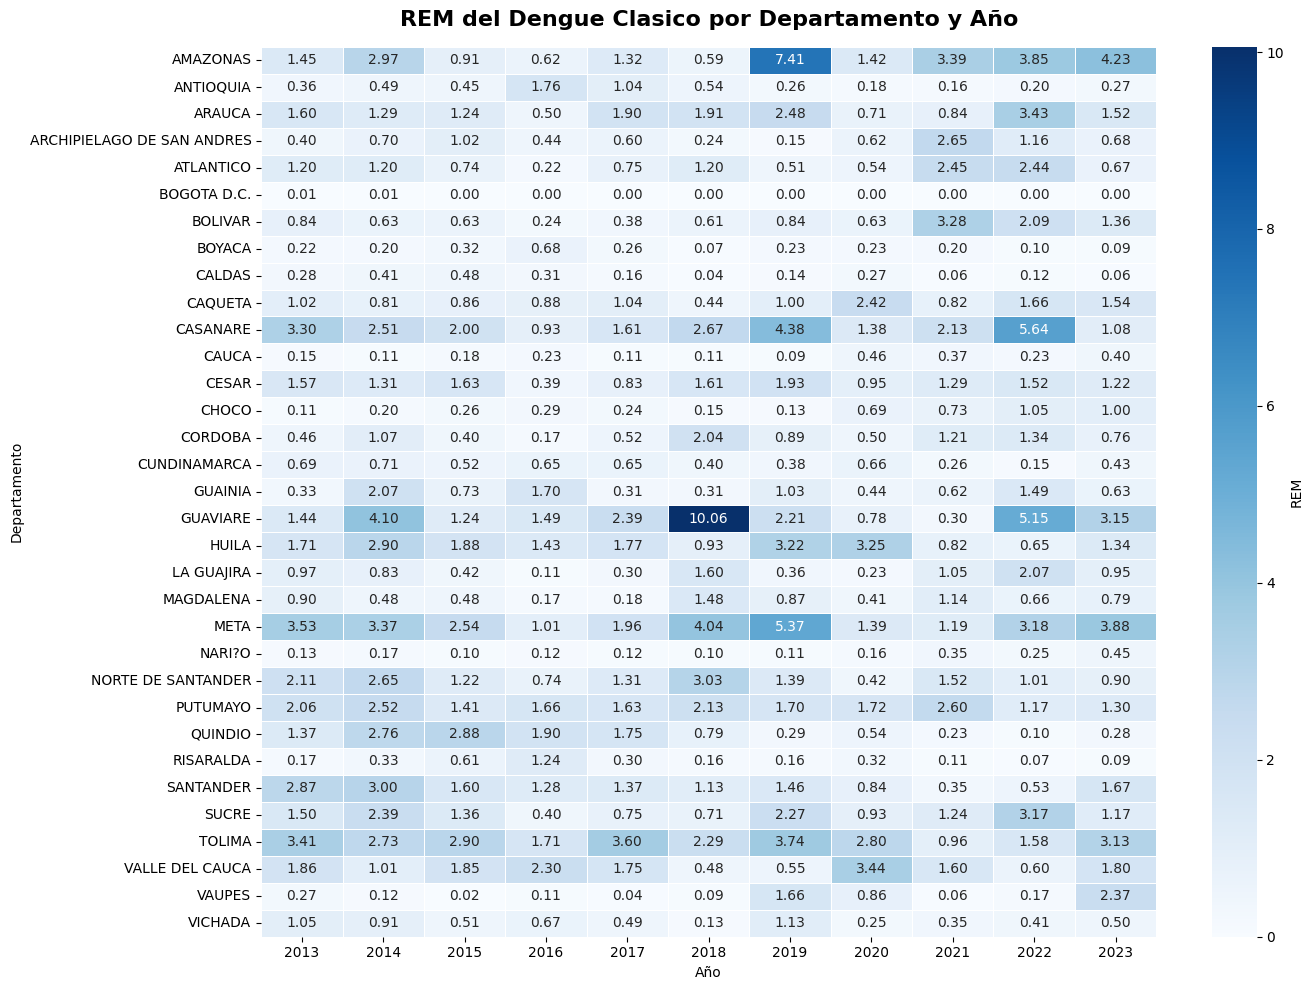

In [ ]:
tabla_clasico_rem = rem_clasico.pivot(index="departamento", columns="anio", values="rem").fillna(0)

# === 3. Graficar heatmap ===
plt.figure(figsize=(14, 10))
sns.heatmap(tabla_clasico_rem, cmap="Blues", annot=True, fmt=".2f", linewidths=0.5, cbar_kws={'label': 'REM'})

plt.title("REM del Dengue Clasico por Departamento y Año", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Año")
plt.ylabel("Departamento")
plt.tight_layout()
plt.show()

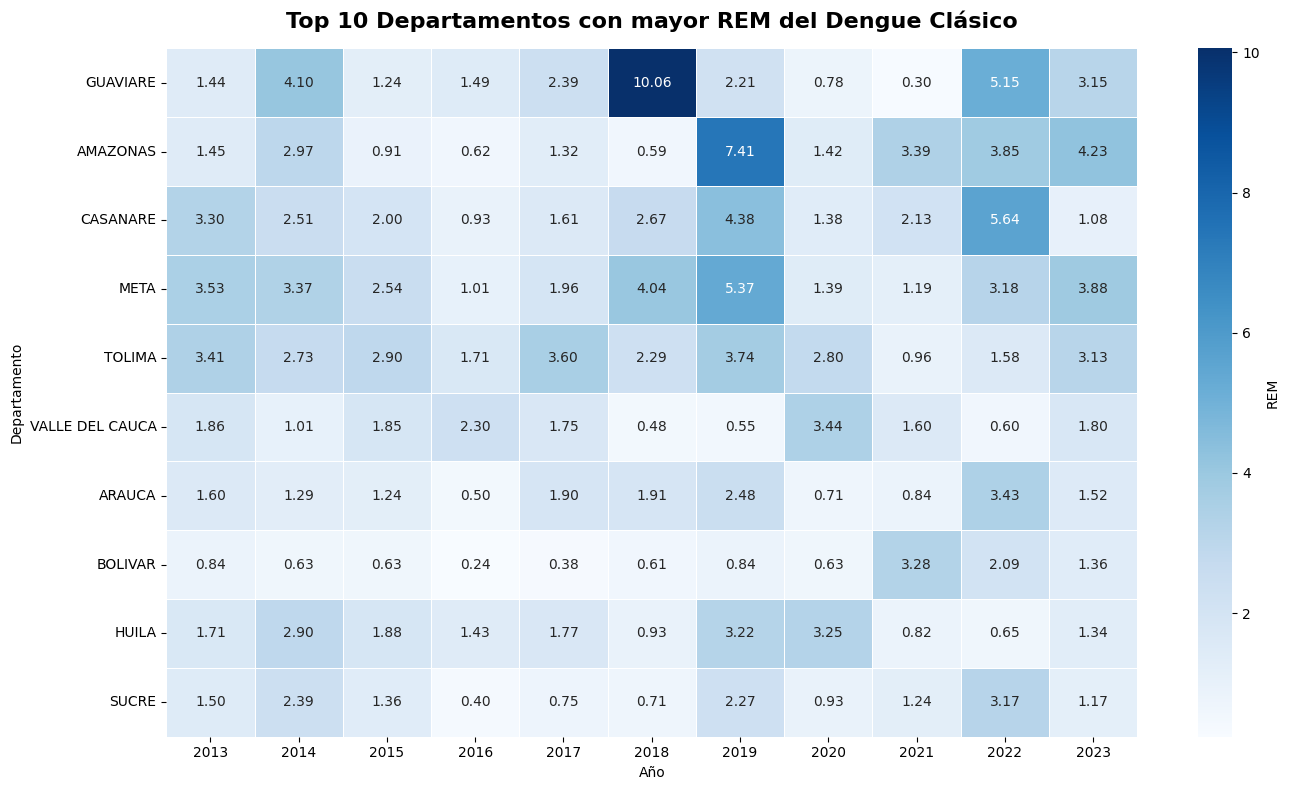

In [ ]:


# === 1. Pivotear ===
tabla_clasico_rem = rem_clasico.pivot(
    index="departamento", 
    columns="anio", 
    values="rem"
).fillna(0)

# === 2. Seleccionar top 10 departamentos con mayores valores de REM ===
top10_departamentos = (
    tabla_clasico_rem.max(axis=1)  # máximo de cada depto en todos los años
    .nlargest(10)                  # los 10 más altos
    .index                         # nombres de los deptos
)
tabla_top10 = tabla_clasico_rem.loc[top10_departamentos]

# === 3. Graficar heatmap ===
plt.figure(figsize=(14, 8))
sns.heatmap(
    tabla_top10,
    cmap="Blues",
    annot=True,
    fmt=".2f",              # <-- mostrar con 2 decimales
    linewidths=0.5,
    cbar_kws={'label': 'REM'}
)

plt.title("Top 10 Departamentos con mayor REM del Dengue Clásico", 
          fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Año")
plt.ylabel("Departamento")
plt.tight_layout()
plt.show()


In [ ]:
# === 1. Aplanar la tabla a formato largo ===
df_long = tabla_clasico_rem.reset_index().melt(
    id_vars="departamento", 
    var_name="anio", 
    value_name="rem"
)

# === 2. Ordenar por rem descendente y tomar los 10 más altos ===
top10_rem = df_long.sort_values(by="rem", ascending=False).head(10)

# === 3. Mostrar resultado ===
top10_rem


,departamento,anio,rem
182,GUAVIARE,2018,10.059163
198,AMAZONAS,2019,7.409221
307,CASANARE,2022,5.643007
219,META,2019,5.372049
314,GUAVIARE,2022,5.154250
208,CASANARE,2019,4.384685
330,AMAZONAS,2023,4.229248
50,GUAVIARE,2014,4.103420
186,META,2018,4.039955
351,META,2023,3.881751


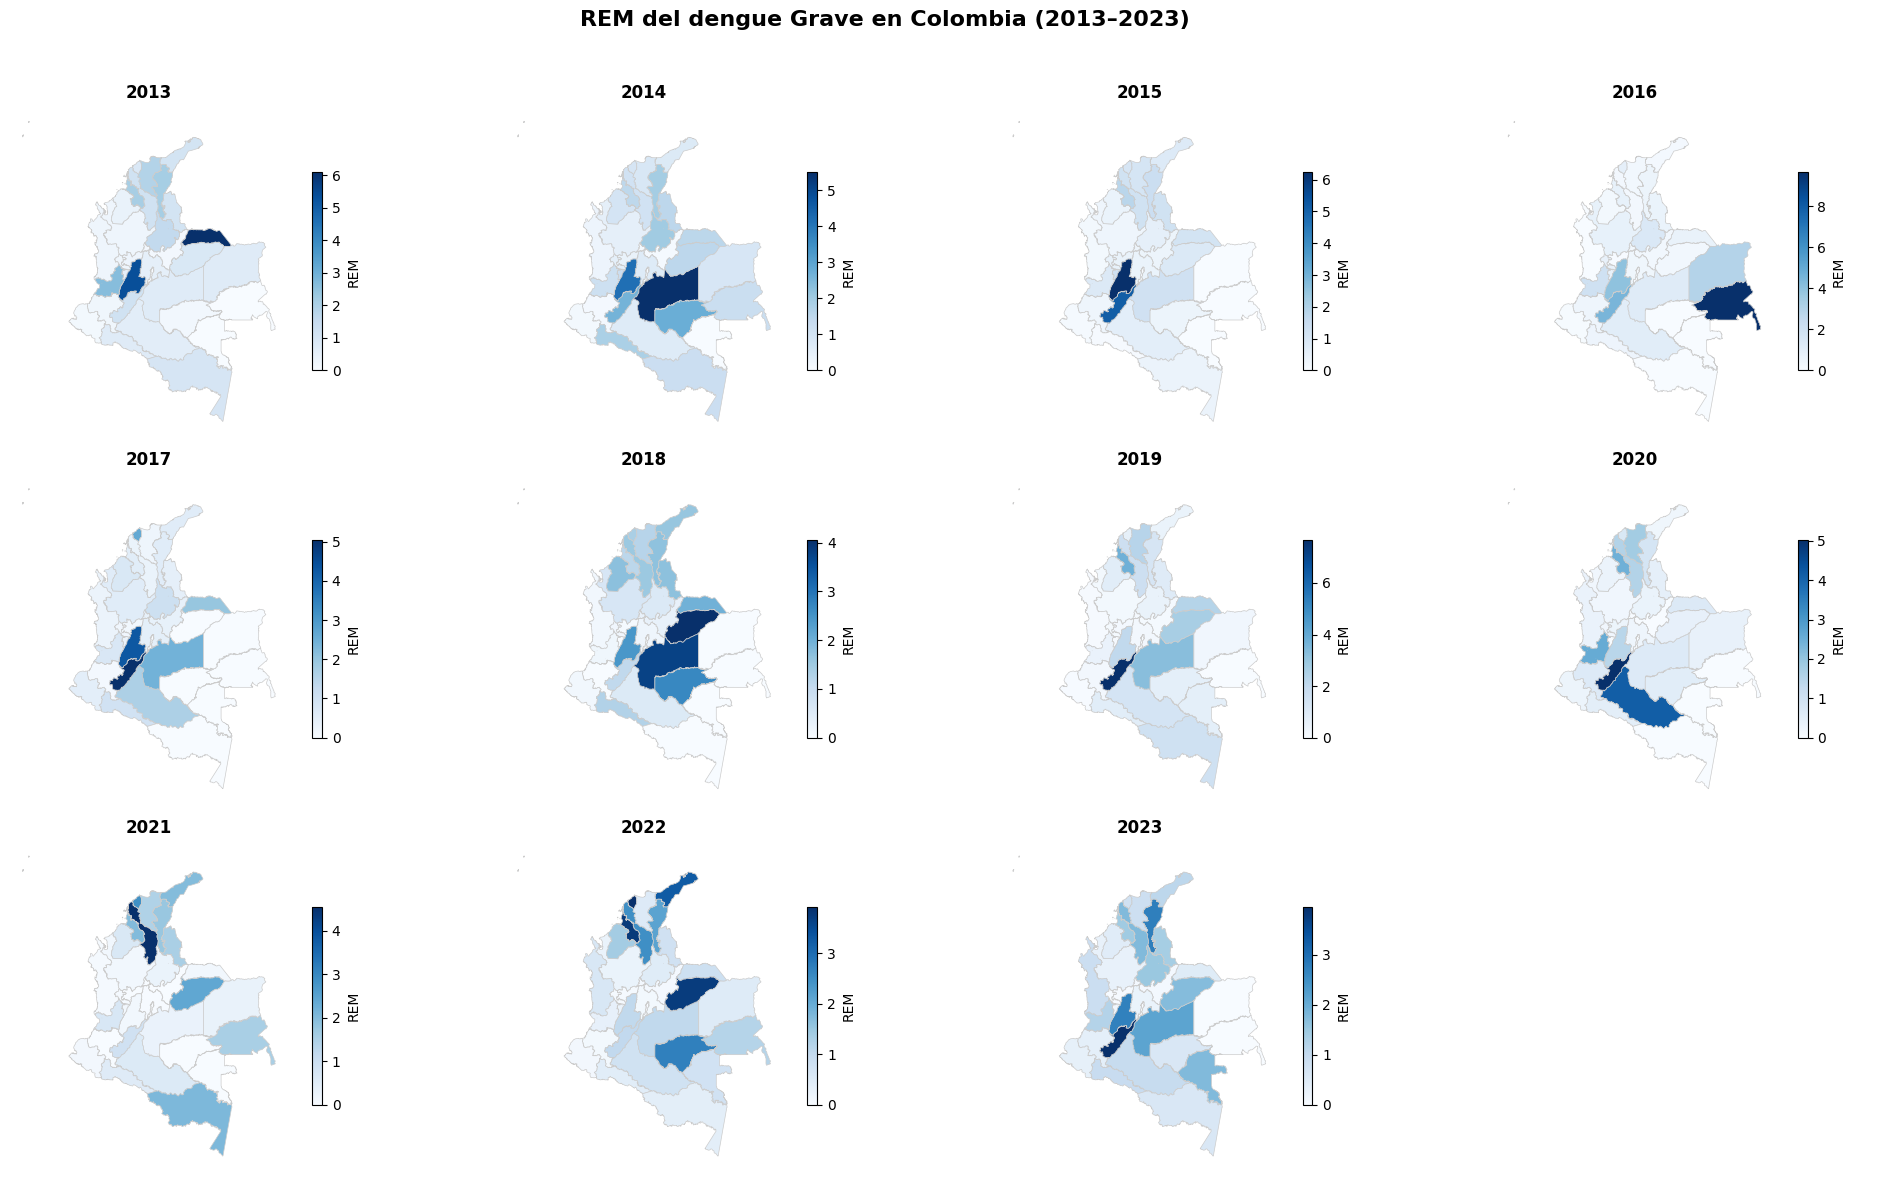

In [ ]:
graficar_panel_rem(rem_grave, shp, evento="Grave")

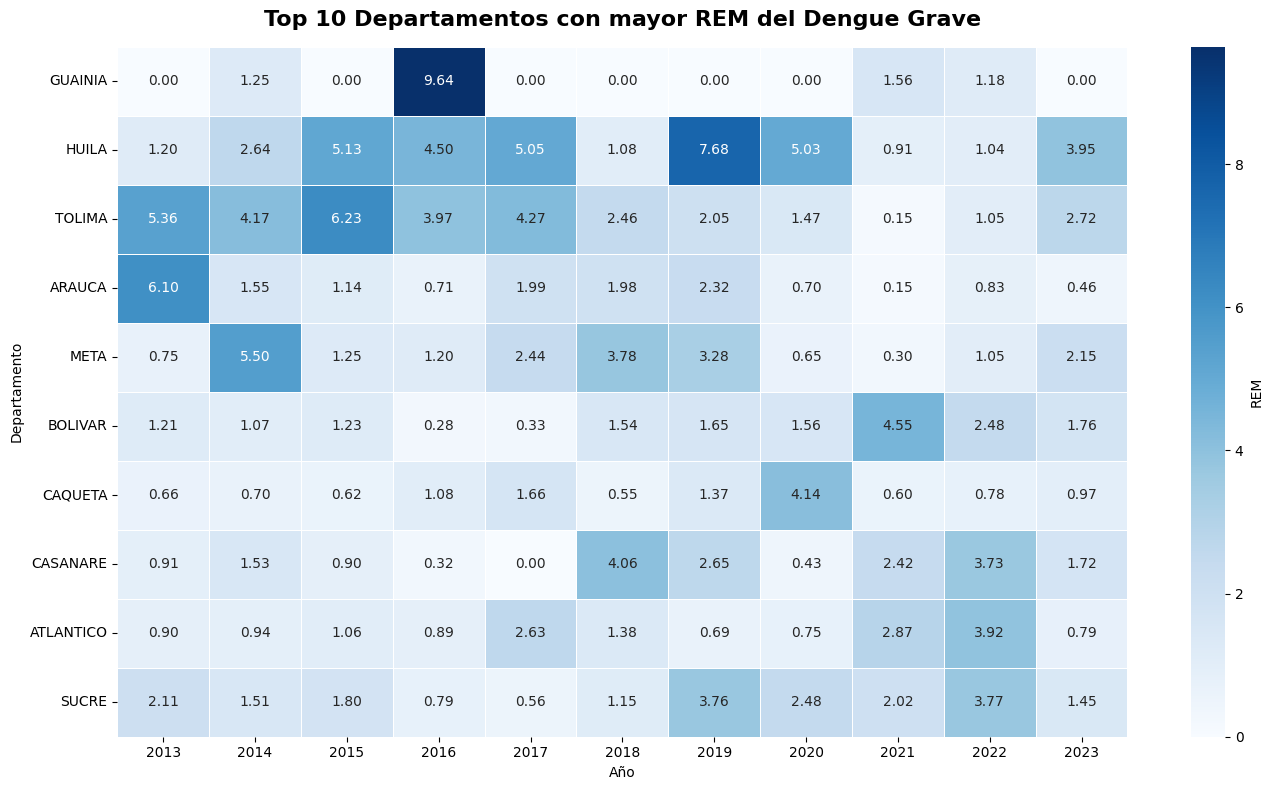

In [ ]:


# === 1. Pivotear ===
tabla_grave_rem = rem_grave.pivot(
    index="departamento", 
    columns="anio", 
    values="rem"
).fillna(0)

# === 2. Seleccionar top 10 departamentos con mayores valores de REM ===
top10_departamentos = (
    tabla_grave_rem.max(axis=1)  # máximo de cada depto en todos los años
    .nlargest(10)                  # los 10 más altos
    .index                         # nombres de los deptos
)
tabla_top10 = tabla_grave_rem.loc[top10_departamentos]

# === 3. Graficar heatmap ===
plt.figure(figsize=(14, 8))
sns.heatmap(
    tabla_top10,
    cmap="Blues",
    annot=True,
    fmt=".2f",              # <-- mostrar con 2 decimales
    linewidths=0.5,
    cbar_kws={'label': 'REM'}
)

plt.title("Top 10 Departamentos con mayor REM del Dengue Grave", 
          fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Año")
plt.ylabel("Departamento")
plt.tight_layout()
plt.show()


In [ ]:
# === 1. Aplanar la tabla a formato largo ===
df_long = tabla_grave_rem.reset_index().melt(
    id_vars="departamento", 
    var_name="anio", 
    value_name="rem"
)

# === 2. Ordenar por rem descendente y tomar los 10 más altos ===
top10_rem = df_long.sort_values(by="rem", ascending=False).head(10)

# === 3. Mostrar resultado ===
top10_rem


,departamento,anio,rem
115,GUAINIA,2016,9.640146
216,HUILA,2019,7.679201
95,TOLIMA,2015,6.231520
2,ARAUCA,2013,6.096377
54,META,2014,5.503307
29,TOLIMA,2013,5.359629
84,HUILA,2015,5.127114
150,HUILA,2017,5.052288
249,HUILA,2020,5.032080
270,BOLIVAR,2021,4.550099


In [ ]:
df1 = pd.read_csv(r"Data\Clasico\REM_Clasico_Periodo.csv")

def graficar_periodos(df, shp, evento=None):
    """
    Grafica un panel de mapas del REM de dengue en Colombia por años,
    cada uno con su escala individual.
    
    Parámetros:
        df (pd.DataFrame): datos con columnas [departamento, anio, rem].
        shp (gpd.GeoDataFrame): shapefile de Colombia con columna DPTO_CNMBR.
        evento (str, opcional): tipo de evento ("Clásico", "Grave", etc.).
    """

    # === 1. Normalizar nombres ===
    df["departamento"] = df["departamento"].str.upper().str.strip()
    shp["DPTO_CNMBR"] = shp["DPTO_CNMBR"].str.upper().str.strip()

    # === 2. Lista de años únicos ordenados ===
    anios = sorted(df["periodo"].unique())

    # === 3. Crear figure y ejes ===
    ncols = 3
    nrows = (len(anios) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 12))
    axes = axes.flatten()

    for i, anio in enumerate(anios):
        ax = axes[i]
        df_anio = df[df["periodo"] == anio]
        gdf_anio = shp.merge(df_anio, left_on="DPTO_CNMBR", right_on="departamento", how="left")
        gdf_anio["rem"] = gdf_anio["rem"].fillna(0)

        vmin = gdf_anio["rem"].min()
        vmax = gdf_anio["rem"].max()

        # Graficar mapa
        gdf_anio.plot(
            column="rem",
            cmap="Blues",
            linewidth=0.5,
            edgecolor="0.8",
            vmin=vmin, vmax=vmax,
            ax=ax,
            legend=True,
            legend_kwds={"shrink": 0.6, "label": "rem"}
        )

        ax.set_title(str(anio), fontsize=12, fontweight="bold")
        ax.axis("off")

    # Ocultar subplots vacíos
    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    # === 4. Título global ===
    titulo = f"REM del dengue {evento or 'general'} en Colombia ({anios[0]}–{anios[-1]})"
    fig.suptitle(titulo, fontsize=16, fontweight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


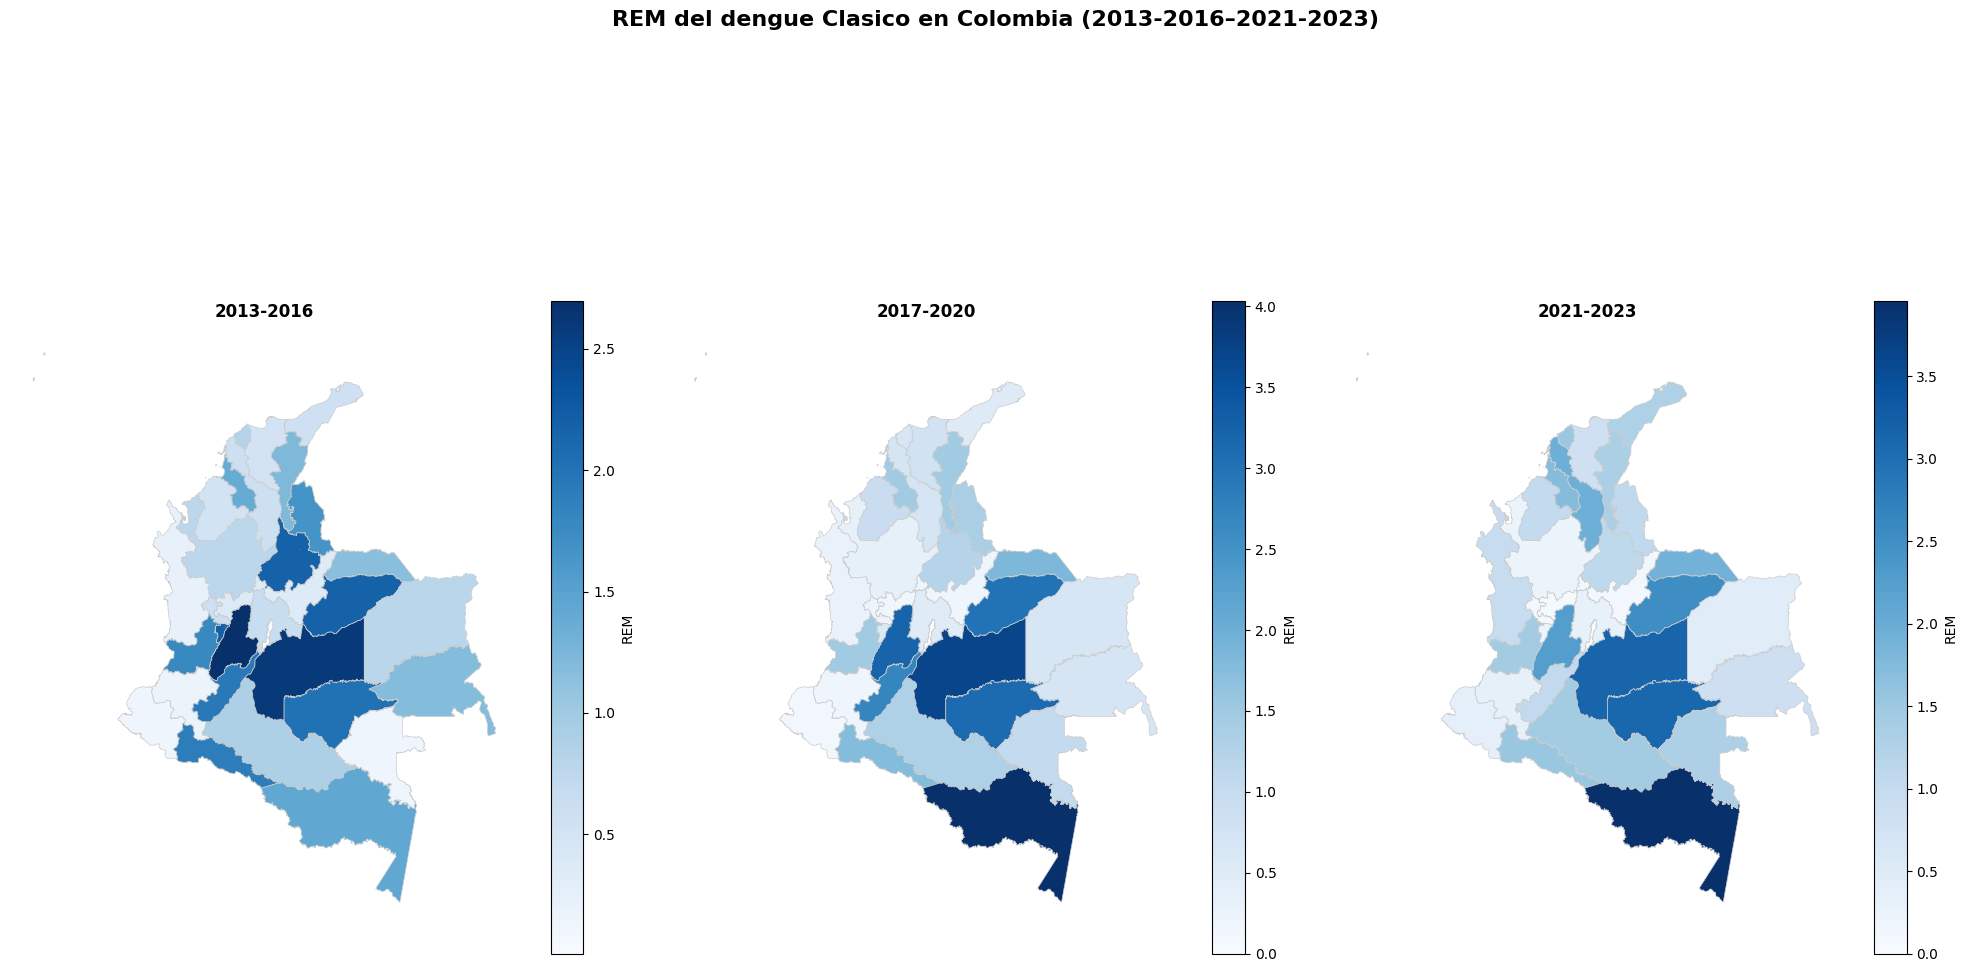

In [ ]:
graficar_periodos(df1, shp, evento="Clasico")

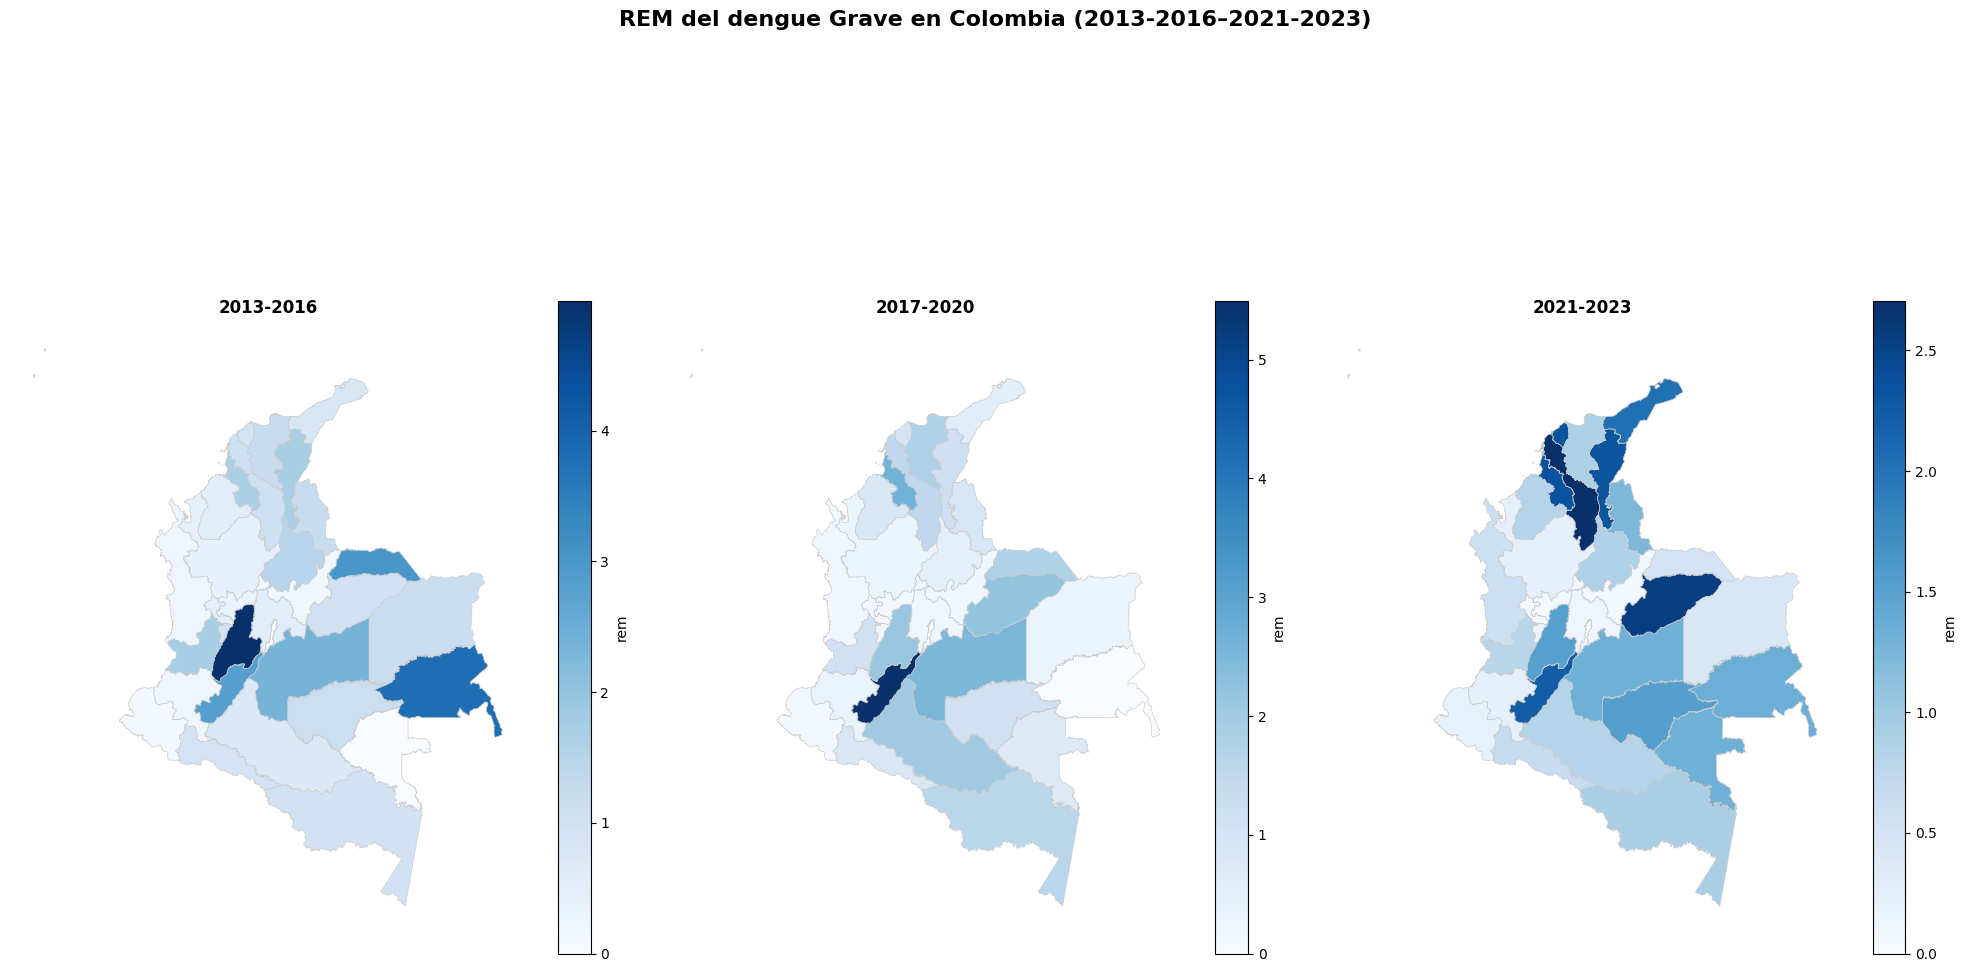

In [ ]:
df2 = pd.read_csv(r"Data\Grave\REM_Grave_Periodo.csv")
graficar_periodos(df2, shp, evento="Grave")

### *REM*

In [ ]:
rem_clasico = pd.read_csv(r"Data\Clasico\REM_Clasico_Largo.csv")
rem_grave = pd.read_csv(r"Data\Grave\REM_Grave_Largo.csv")

In [ ]:

def graficar_panel_rem(df, shp, evento=None):
    """
    Grafica un panel de mapas del REM de dengue en Colombia por años,
    cada uno con su escala individual.
    
    Parámetros:
        df (pd.DataFrame): datos con columnas [departamento, anio, rem].
        shp (gpd.GeoDataFrame): shapefile de Colombia con columna DPTO_CNMBR.
        evento (str, opcional): tipo de evento ("Clásico", "Grave", etc.).
    """

    # === 1. Normalizar nombres ===
    df["departamento"] = df["departamento"].str.upper().str.strip()
    shp["DPTO_CNMBR"] = shp["DPTO_CNMBR"].str.upper().str.strip()

    # === 2. Lista de años únicos ordenados ===
    anios = sorted(df["anio"].unique())

    # === 3. Crear figure y ejes ===
    ncols = 4
    nrows = (len(anios) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 12))
    axes = axes.flatten()

    for i, anio in enumerate(anios):
        ax = axes[i]
        df_anio = df[df["anio"] == anio]
        gdf_anio = shp.merge(df_anio, left_on="DPTO_CNMBR", right_on="departamento", how="left")
        gdf_anio["rem"] = gdf_anio["rem"].fillna(0)

        vmin = gdf_anio["rem"].min()
        vmax = gdf_anio["rem"].max()

        # Graficar mapa
        gdf_anio.plot(
            column="rem",
            cmap="Greens",
            linewidth=0.5,
            edgecolor="0.8",
            vmin=vmin, vmax=vmax,
            ax=ax,
            legend=True,
            legend_kwds={"shrink": 0.6, "label": "REM"}
        )

        ax.set_title(str(anio), fontsize=12, fontweight="bold")
        ax.axis("off")

    # Ocultar subplots vacíos
    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    # === 4. Título global ===
    titulo = f"REM del dengue {evento or 'general'} en Colombia ({anios[0]}–{anios[-1]})"
    fig.suptitle(titulo, fontsize=16, fontweight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


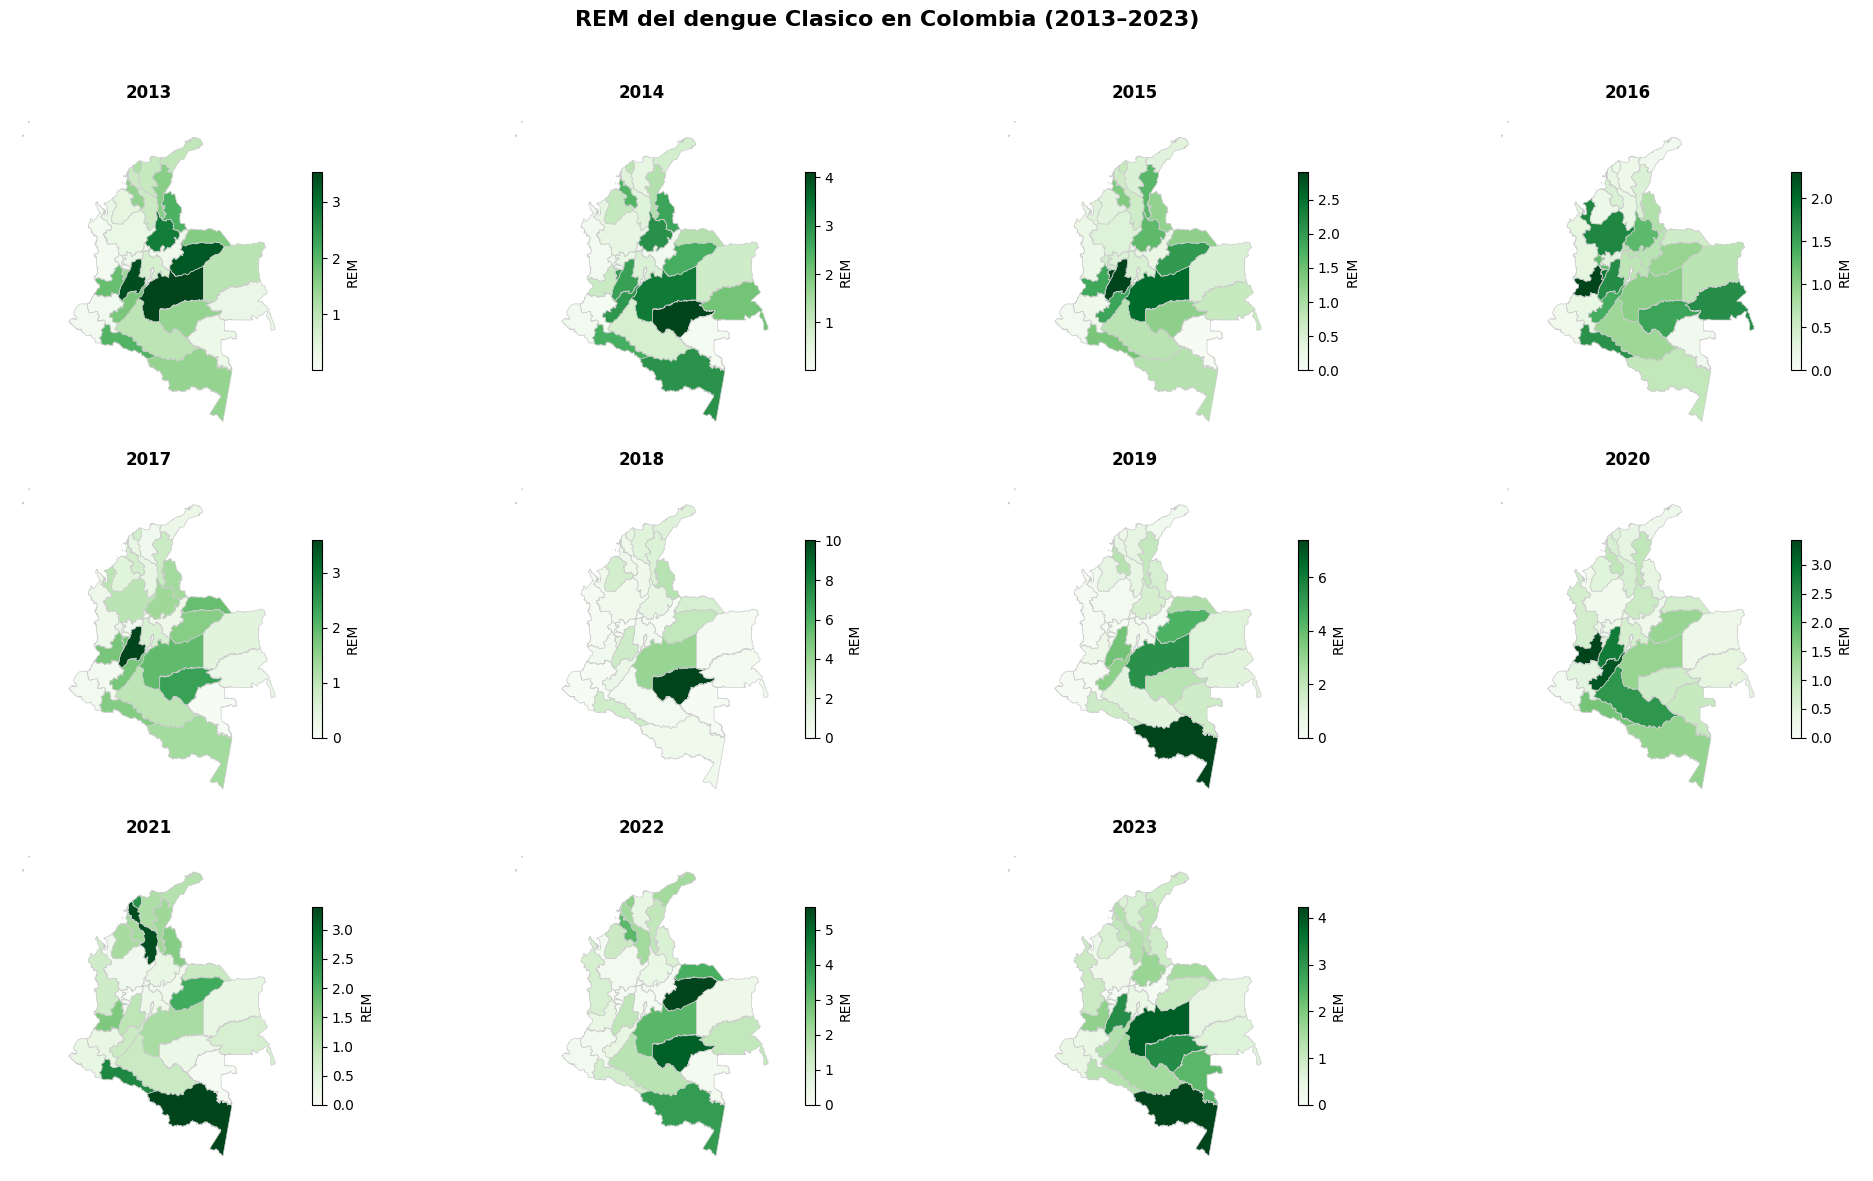

In [ ]:
graficar_panel_rem(rem_clasico, shp, evento="Clasico")

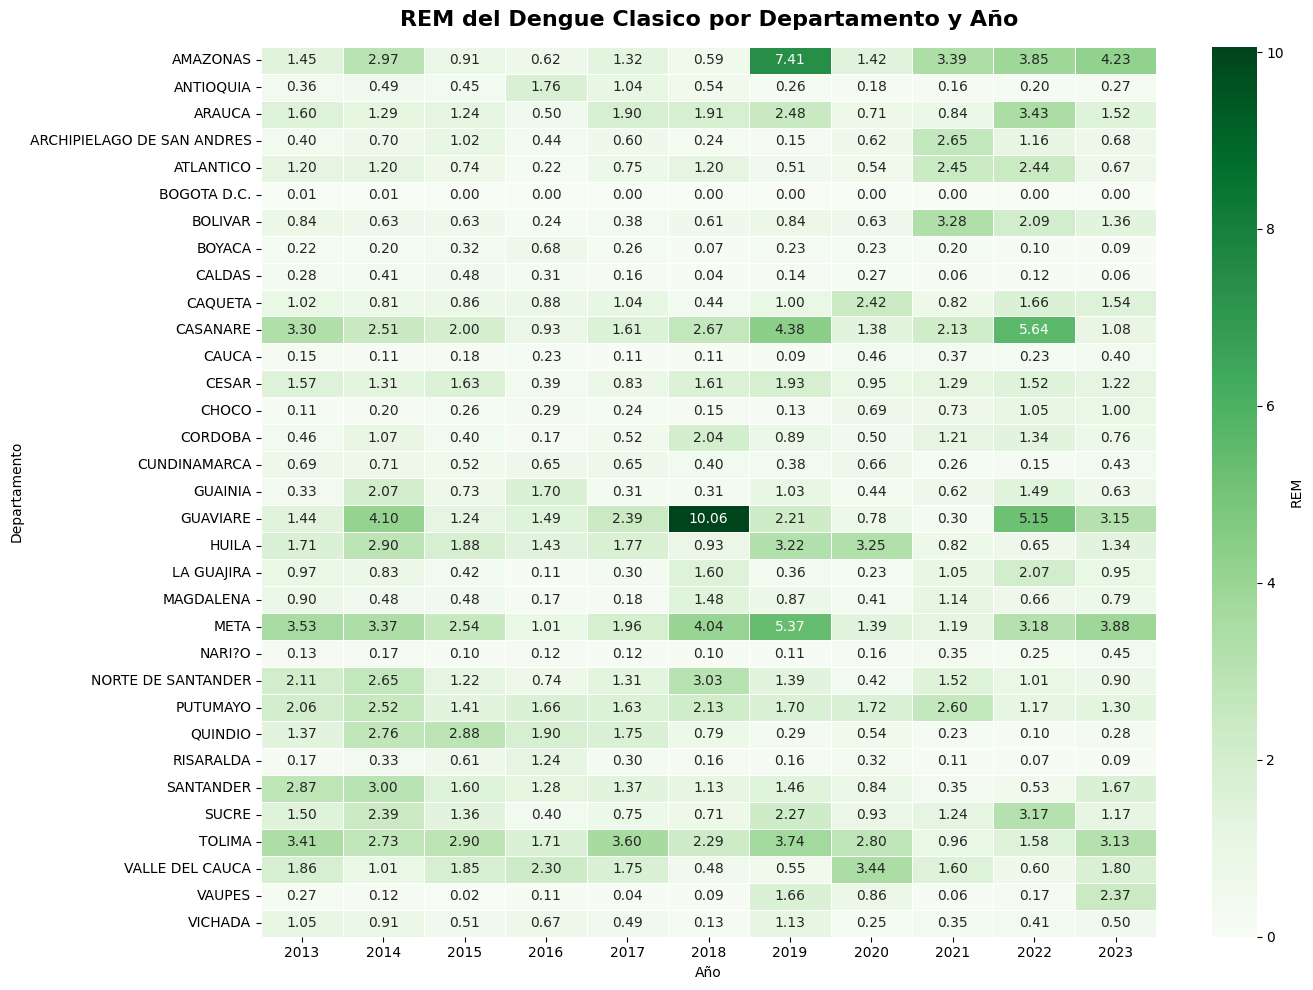

In [ ]:
tabla_clasico_rem = rem_clasico.pivot(index="departamento", columns="anio", values="rem").fillna(0)

# === 3. Graficar heatmap ===
plt.figure(figsize=(14, 10))
sns.heatmap(tabla_clasico_rem, cmap="Greens", annot=True, fmt=".2f", linewidths=0.5, cbar_kws={'label': 'REM'})

plt.title("REM del Dengue Clasico por Departamento y Año", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Año")
plt.ylabel("Departamento")
plt.tight_layout()
plt.show()

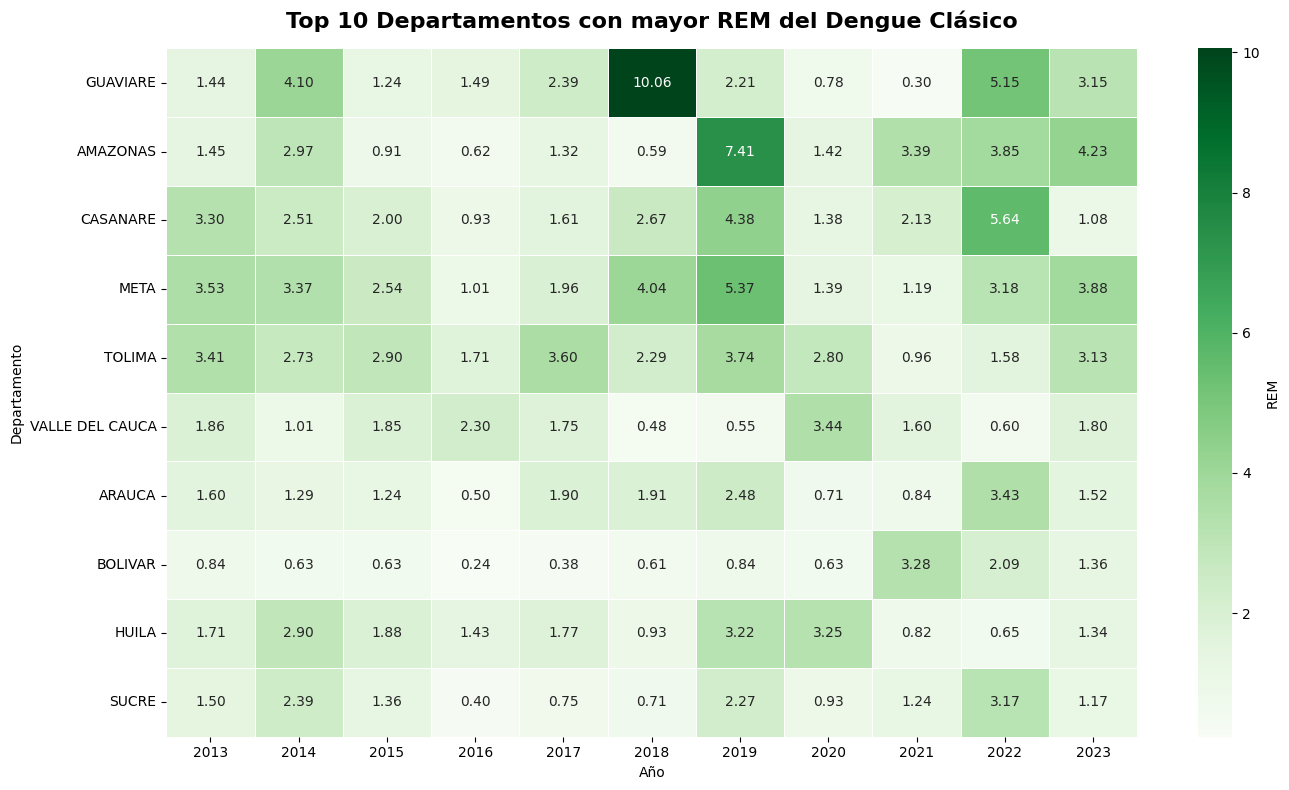

In [ ]:


# === 1. Pivotear ===
tabla_clasico_rem = rem_clasico.pivot(
    index="departamento", 
    columns="anio", 
    values="rem"
).fillna(0)

# === 2. Seleccionar top 10 departamentos con mayores valores de REM ===
top10_departamentos = (
    tabla_clasico_rem.max(axis=1)  # máximo de cada depto en todos los años
    .nlargest(10)                  # los 10 más altos
    .index                         # nombres de los deptos
)
tabla_top10 = tabla_clasico_rem.loc[top10_departamentos]

# === 3. Graficar heatmap ===
plt.figure(figsize=(14, 8))
sns.heatmap(
    tabla_top10,
    cmap="Greens",
    annot=True,
    fmt=".2f",              # <-- mostrar con 2 decimales
    linewidths=0.5,
    cbar_kws={'label': 'REM'}
)

plt.title("Top 10 Departamentos con mayor REM del Dengue Clásico", 
          fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Año")
plt.ylabel("Departamento")
plt.tight_layout()
plt.show()


In [ ]:
# === 1. Aplanar la tabla a formato largo ===
df_long = tabla_clasico_rem.reset_index().melt(
    id_vars="departamento", 
    var_name="anio", 
    value_name="rem"
)

# === 2. Ordenar por rem descendente y tomar los 10 más altos ===
top10_rem = df_long.sort_values(by="rem", ascending=False).head(10)

# === 3. Mostrar resultado ===
top10_rem


,departamento,anio,rem
182,GUAVIARE,2018,10.059163
198,AMAZONAS,2019,7.409221
307,CASANARE,2022,5.643007
219,META,2019,5.372049
314,GUAVIARE,2022,5.154250
208,CASANARE,2019,4.384685
330,AMAZONAS,2023,4.229248
50,GUAVIARE,2014,4.103420
186,META,2018,4.039955
351,META,2023,3.881751


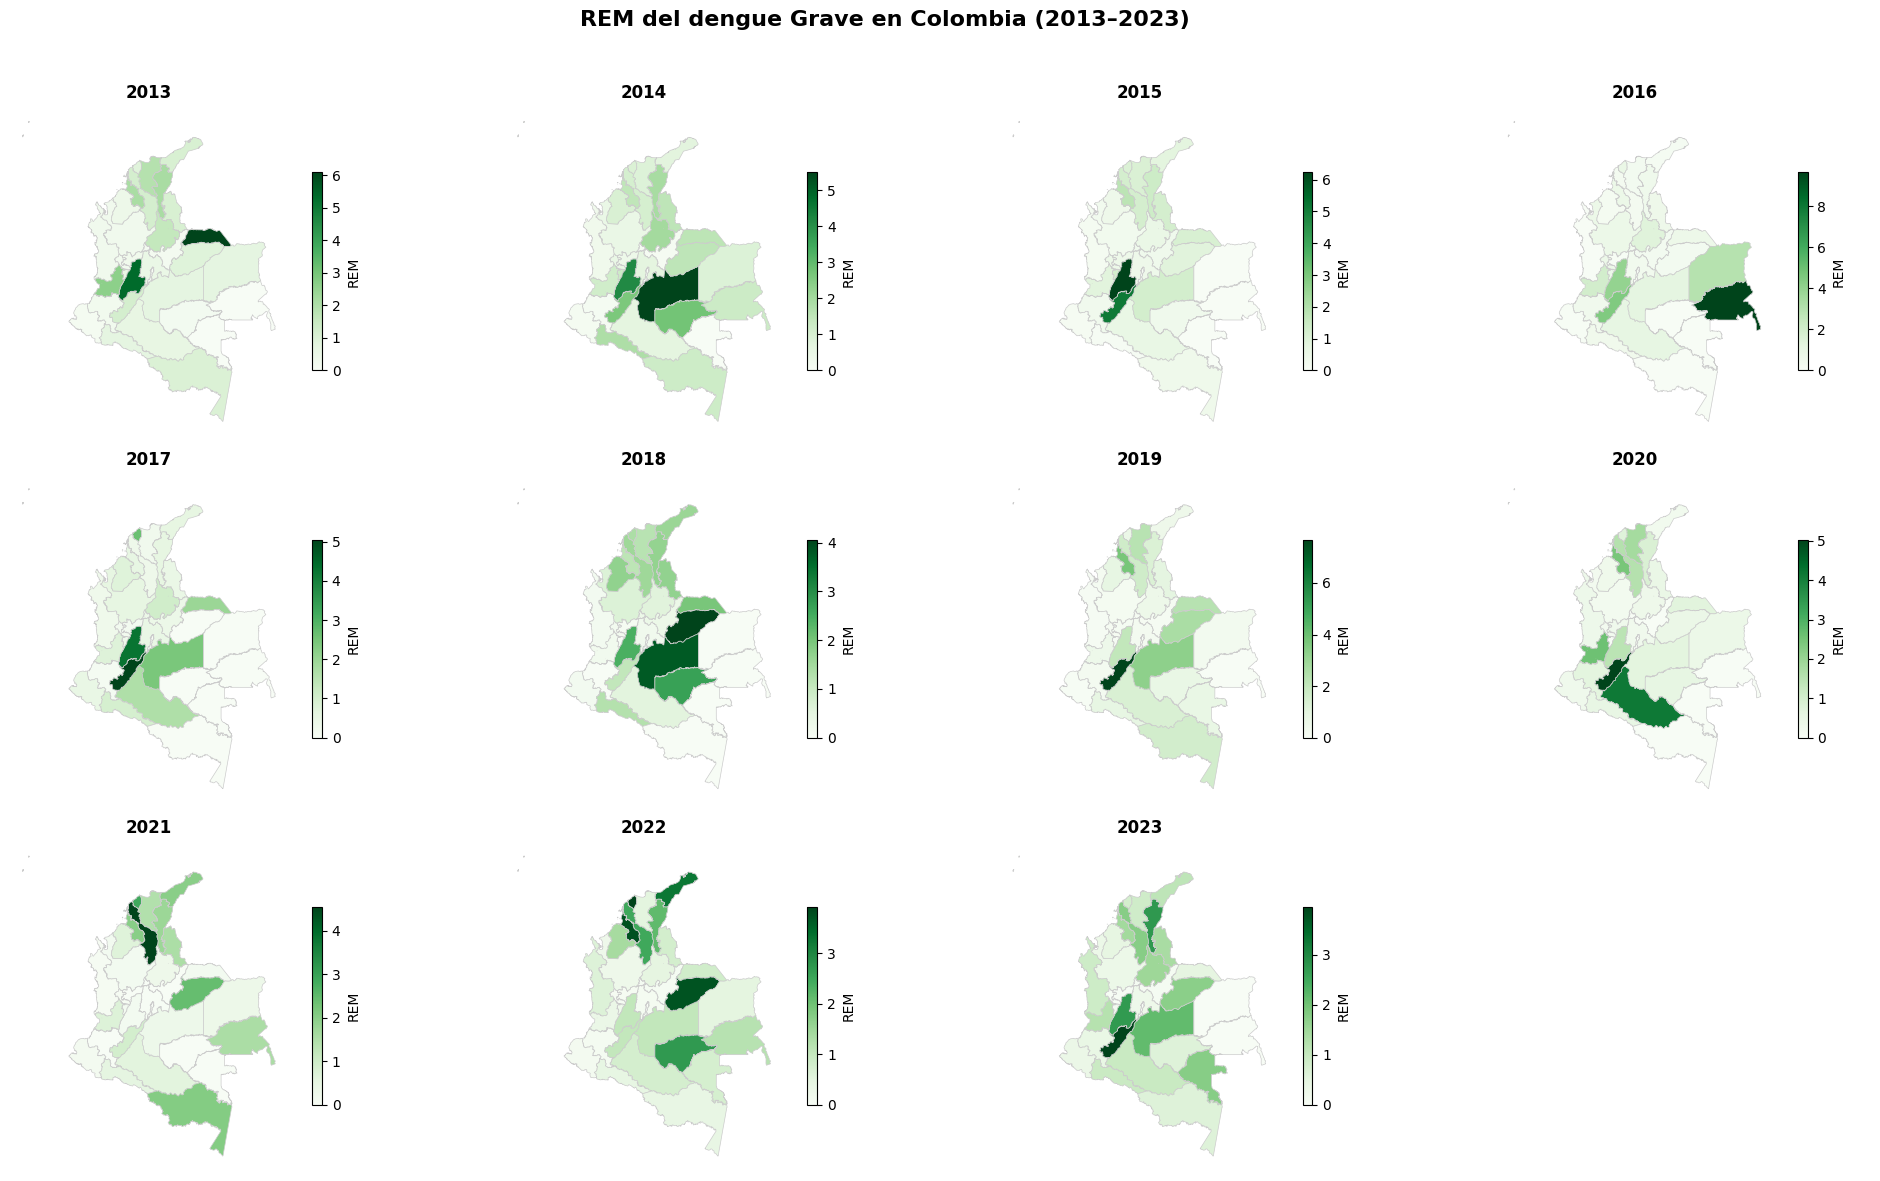

In [ ]:
graficar_panel_rem(rem_grave, shp, evento="Grave")

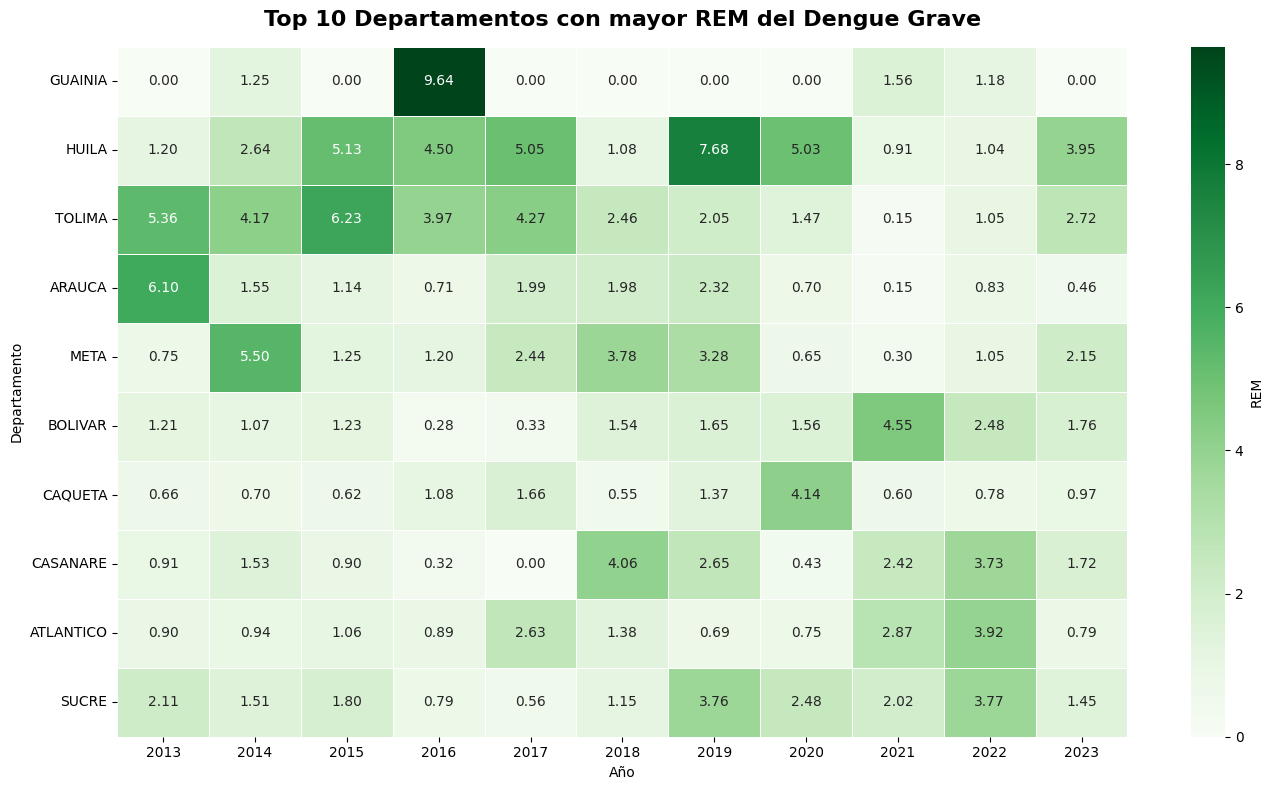

In [ ]:


# === 1. Pivotear ===
tabla_grave_rem = rem_grave.pivot(
    index="departamento", 
    columns="anio", 
    values="rem"
).fillna(0)

# === 2. Seleccionar top 10 departamentos con mayores valores de REM ===
top10_departamentos = (
    tabla_grave_rem.max(axis=1)  # máximo de cada depto en todos los años
    .nlargest(10)                  # los 10 más altos
    .index                         # nombres de los deptos
)
tabla_top10 = tabla_grave_rem.loc[top10_departamentos]

# === 3. Graficar heatmap ===
plt.figure(figsize=(14, 8))
sns.heatmap(
    tabla_top10,
    cmap="Greens",
    annot=True,
    fmt=".2f",              # <-- mostrar con 2 decimales
    linewidths=0.5,
    cbar_kws={'label': 'REM'}
)

plt.title("Top 10 Departamentos con mayor REM del Dengue Grave", 
          fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Año")
plt.ylabel("Departamento")
plt.tight_layout()
plt.show()


In [ ]:
# === 1. Aplanar la tabla a formato largo ===
df_long = tabla_grave_rem.reset_index().melt(
    id_vars="departamento", 
    var_name="anio", 
    value_name="rem"
)

# === 2. Ordenar por rem descendente y tomar los 10 más altos ===
top10_rem = df_long.sort_values(by="rem", ascending=False).head(10)

# === 3. Mostrar resultado ===
top10_rem


,departamento,anio,rem
115,GUAINIA,2016,9.640146
216,HUILA,2019,7.679201
95,TOLIMA,2015,6.231520
2,ARAUCA,2013,6.096377
54,META,2014,5.503307
29,TOLIMA,2013,5.359629
84,HUILA,2015,5.127114
150,HUILA,2017,5.052288
249,HUILA,2020,5.032080
270,BOLIVAR,2021,4.550099
